In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from scipy.stats import linregress

In [2]:
data_clients = pd.read_csv('base_comptoir_espace_table_clients.csv',sep=';')
data_dec_entreprises=pd.read_csv('base_comptoir_espace_table_decisions_entreprises.csv',sep=';')

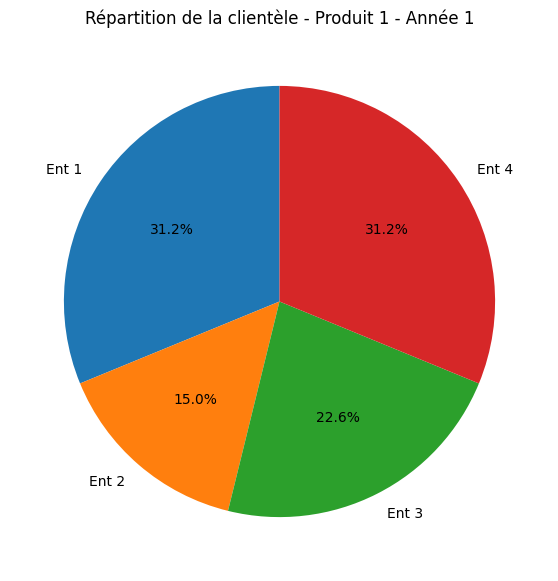

In [3]:
###Diagrammes circulaires Répartition clientèle 
produit_choisi=1
annee_choisie=1

df_client = data_clients.loc[
    (data_clients["CLI_ANNEE"] == annee_choisie)
    & (data_clients["CLI_PROD"] == produit_choisi)
    & (data_clients["CLI_CHOIX"] != 0)
].copy()

repartition = df_client.groupby("CLI_CHOIX").size().sort_index()
labels = [f"Ent {ent}" for ent in repartition.index]

plt.figure(figsize=(7,7))
plt.pie(repartition, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title(f"Répartition de la clientèle - Produit {produit_choisi} - Année {annee_choisie}")
plt.show()


In [4]:
df_evenements=pd.DataFrame({'année':np.random.randint(2020,2023,100),'mois':np.random.randint(1,12,100),'jour':np.random.randint(1,30)})
print(df_evenements.head(10))
print('type mois : ',type(df_evenements.mois[0]))
df_evenements['mois_bis']=df_evenements.mois.astype('str')
print('type mois bis : ',type(df_evenements.mois_bis[0]))
df_evenements['mois_bis']=df_evenements['mois_bis'].str.zfill(2)
df_evenements['date']=df_evenements.année.astype(str)+'-'+df_evenements.mois_bis+'-'+df_evenements.jour.astype(str)
print('type date : ',type(df_evenements['date'][0]))
df_evenements['date']=df_evenements['date'].astype('datetime64[ns]')
print(df_evenements['date'].dtype)
print('durée entre deux premières dates : ',df_evenements['date'][1]-df_evenements['date'][0])

   année  mois  jour
0   2021     3    13
1   2022     4    13
2   2022     4    13
3   2020     1    13
4   2022     7    13
5   2021     4    13
6   2021     5    13
7   2022    10    13
8   2020    10    13
9   2020     2    13
type mois :  <class 'numpy.int64'>
type mois bis :  <class 'str'>
type date :  <class 'str'>
datetime64[ns]
durée entre deux premières dates :  396 days 00:00:00


   ENT_ANNEE  ENT_ID  ENT_PRIX  NB_VENTES        CA
0          1       1      5000       1500   7500000
4          2       1      5500       2249  12369500
1          1       2      4500        719   3235500
5          2       2      4500       1383   6223500
2          1       3      5700       1088   6201600
6          2       3      5700        397   2262900
3          1       4      6700       1500  10050000
7          2       4      6700        997   6679900


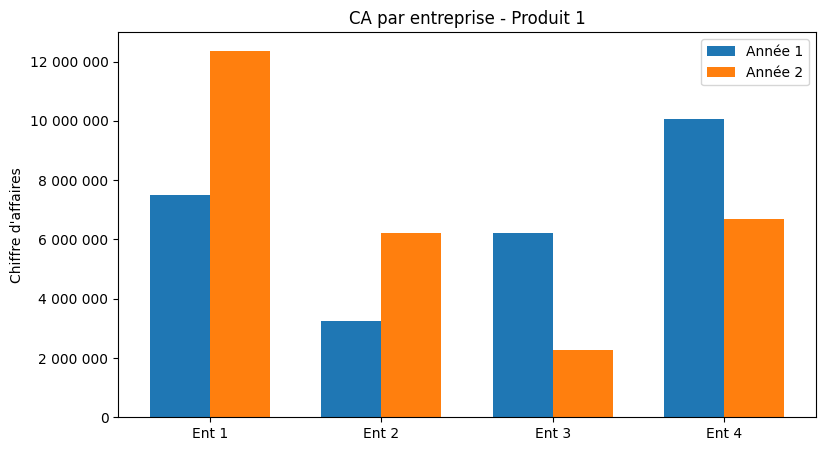

In [5]:
###DIAGRAMMES BARRES CA 2 ANNEES
#Retrouver un tableau donnant les chiffres d'affaires voulus

#Aide pour la réalisation du graphique
'''fig, ax=plt.subplots()
width=0.3
ax.bar(....,-width,align='edge',label='Année 1')
ax.bar(....,width,align='edge',label='Année 2')
ax.set_xticks(....) #Pour changer les étiquettes sur les abscisses
ax.get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x,p:format(int(x),',').replace(',',' ')))#Pour changer le format des étiquettes sur les ordonnées (pas à savoir faire)'''

produit_choisi = 1

ventes = (
    data_clients.loc[
        (data_clients["CLI_PROD"] == produit_choisi) & (data_clients["CLI_CHOIX"] != 0),
        ["CLI_ANNEE", "CLI_CHOIX"]
    ]
    .groupby(["CLI_ANNEE", "CLI_CHOIX"])
    .size()
    .reset_index(name="NB_VENTES")
)

decisions = data_dec_entreprises.loc[
    data_dec_entreprises["ENT_PROD"] == produit_choisi,
    ["ENT_ANNEE", "ENT_ID", "ENT_PRIX"]
].copy()

tableau_ca = decisions.merge(
    ventes,
    left_on=["ENT_ANNEE", "ENT_ID"],
    right_on=["CLI_ANNEE", "CLI_CHOIX"],
    how="left"
)
tableau_ca["NB_VENTES"] = tableau_ca["NB_VENTES"].fillna(0).astype(int)
tableau_ca["CA"] = tableau_ca["ENT_PRIX"] * tableau_ca["NB_VENTES"]
tableau_ca = tableau_ca[["ENT_ANNEE", "ENT_ID", "ENT_PRIX", "NB_VENTES", "CA"]].sort_values(["ENT_ID", "ENT_ANNEE"])

print(tableau_ca)

pivot_ca = tableau_ca.pivot(index="ENT_ID", columns="ENT_ANNEE", values="CA").fillna(0)
entreprises = pivot_ca.index.tolist()
x = np.arange(len(entreprises))

fig, ax = plt.subplots(figsize=(9,5))
width = 0.35
ax.bar(x - width/2, pivot_ca.get(1, pd.Series(0, index=entreprises)), width, label='Année 1')
ax.bar(x + width/2, pivot_ca.get(2, pd.Series(0, index=entreprises)), width, label='Année 2')
ax.set_xticks(x)
ax.set_xticklabels([f"Ent {e}" for e in entreprises])
ax.set_ylabel("Chiffre d'affaires")
ax.set_title(f"CA par entreprise - Produit {produit_choisi}")
ax.get_yaxis().set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x,p: format(int(x), ',').replace(',', ' ')))
ax.legend()
plt.show()


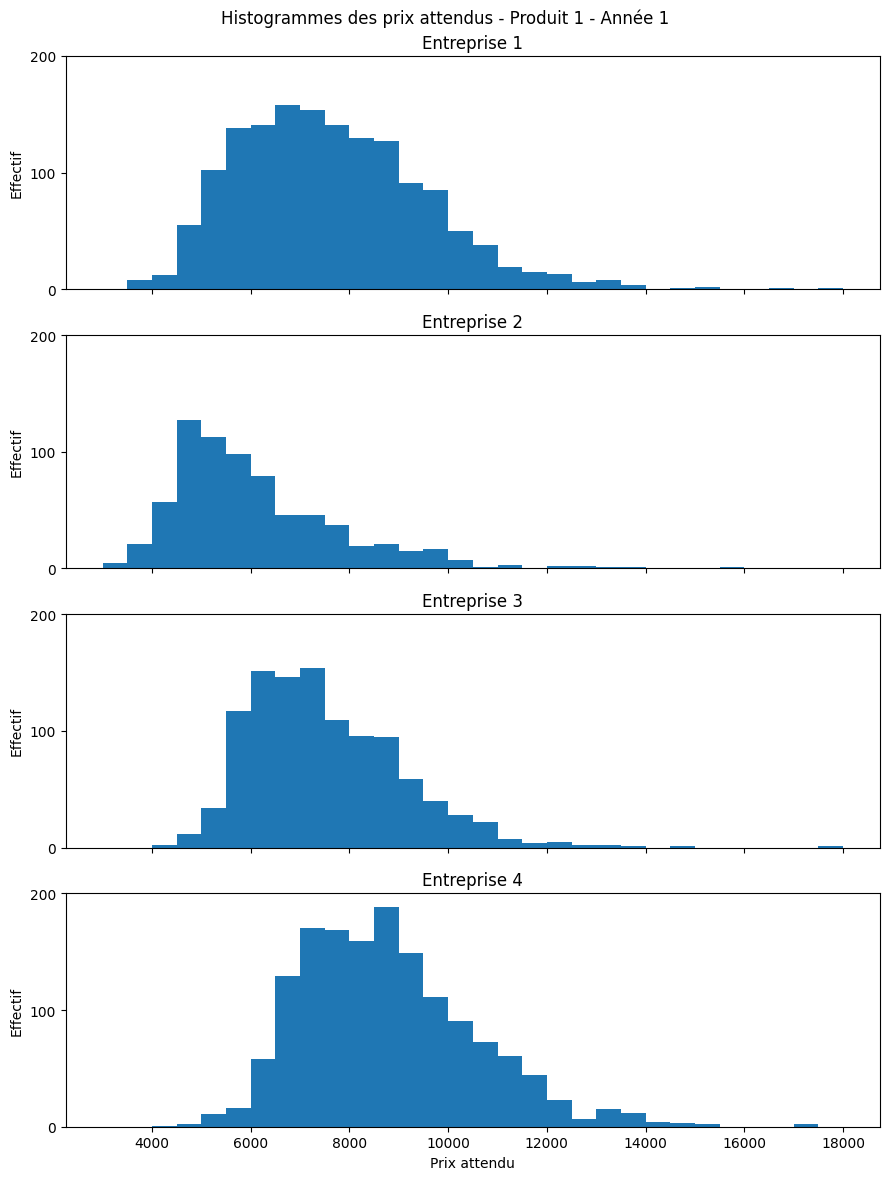

In [6]:
###HISTOGRAMMES PRIX ATTENDUS POUR UN PRODUIT SUR UNE ANNEE
produit_choisi=1
annee_choisie=1
#Rappel : la fonction plt.hist effectue elle-même le calcul des effectifs à l'intérieur des intervalles qu'on peut spécifier 
#ou qui sont calculés en en donnant le nombre (dans les deux cas on renseigne le paramètres bins). On peut par ailleurs récupérer les effectifs
#via effectifs,_,_=plt.hist(...)

#Aide pour générer ces intervalles : par exemple avec des valeurs qui iraient de 22.3 à 113 et qu'on souhaitait des intervalles d'amplitude 5 de 20 
#à 113 on peut remarquer que 22/5 nous donne le nombre de "cinquaines" à arrondir à l'unité inférieure pour avoir ensuite le premier multiple de cinq directement inférieur
# Les intervalles vont donc de int(22.3/5)*5 à (int(113/5)+1)*5

#Pour mieux comparer les clientèles des différentes entreprises on souhaite avoir la même échelle et les mêmes graduations qu'on déterminera
#Cela peut se faire en utilisant :
#ax.set_yticks(liste des graduations)
#ax.set_ybound(min echelle, max echelle)

df_client = data_clients.loc[
    (data_clients["CLI_ANNEE"] == annee_choisie)
    & (data_clients["CLI_PROD"] == produit_choisi)
    & (data_clients["CLI_CHOIX"] != 0)
].copy()

amplitude = 500
prix_min = int(df_client["CLI_PRIX"].min() / amplitude) * amplitude
prix_max = (int(df_client["CLI_PRIX"].max() / amplitude) + 1) * amplitude
bins = np.arange(prix_min, prix_max + amplitude, amplitude)

entreprises = sorted(df_client["CLI_CHOIX"].unique())
max_effectif = 0
for ent in entreprises:
    effectifs, _ = np.histogram(df_client.loc[df_client["CLI_CHOIX"] == ent, "CLI_PRIX"], bins=bins)
    max_effectif = max(max_effectif, effectifs.max())

graduations = np.arange(0, max_effectif + 100, 100)
fig, axes = plt.subplots(len(entreprises), 1, figsize=(9, 3*len(entreprises)), sharex=True)
if len(entreprises) == 1:
    axes = [axes]

for ax, ent in zip(axes, entreprises):
    ax.hist(df_client.loc[df_client["CLI_CHOIX"] == ent, "CLI_PRIX"], bins=bins)
    ax.set_title(f"Entreprise {ent}")
    ax.set_ylabel("Effectif")
    ax.set_yticks(graduations)
    if len(graduations) > 0:
        ax.set_ybound(0, graduations[-1])

axes[-1].set_xlabel("Prix attendu")
plt.suptitle(f"Histogrammes des prix attendus - Produit {produit_choisi} - Année {annee_choisie}")
plt.tight_layout()
plt.show()


Pente = 0.1158
Ordonnée à l'origine = 370.53
Coefficient de corrélation = 0.8083


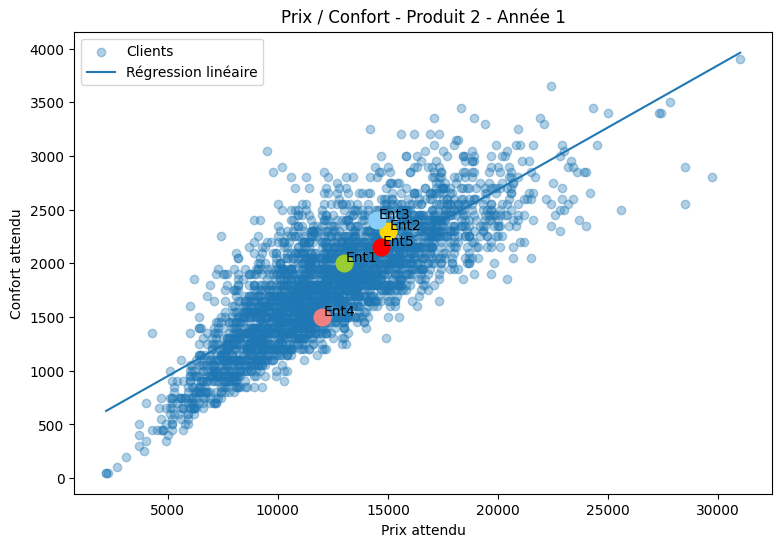

In [7]:
###Nuage de points Prix/Confort
produit_choisi=2
annee_choisie=1

df_client = data_clients.loc[
    (data_clients["CLI_ANNEE"] == annee_choisie)
    & (data_clients["CLI_PROD"] == produit_choisi)
].copy()

#Pour représenter la droite :
res_reg=linregress(df_client["CLI_PRIX"], df_client["CLI_CONFORT"])
a=res_reg.slope
b=res_reg.intercept
coef_cor=res_reg.rvalue
print(f"Pente = {a:.4f}")
print(f"Ordonnée à l'origine = {b:.2f}")
print(f"Coefficient de corrélation = {coef_cor:.4f}")
#La droite peut être obtenue en calculant le confort attendu d'après le modèle en fonction du prix attendu (on peut se contenter de le faire
# pour deux points en choisissant les prix extrêmes attendus par la clientèle)

prix_extremes = np.array([df_client["CLI_PRIX"].min(), df_client["CLI_PRIX"].max()])
confort_modele = a * prix_extremes + b

plt.figure(figsize=(9,6))
plt.scatter(df_client["CLI_PRIX"], df_client["CLI_CONFORT"], alpha=0.35, label="Clients")
plt.plot(prix_extremes, confort_modele, label="Régression linéaire")

#Pour représenter les points montrant les positionnements des différentes entreprises :
#On peut faire une boucle sur l'ensemble des entreprises concernées par la commercialisation d'un voyage en utilisant une couleur différente pour
#chaque entreprise
couleurs = ['yellowgreen', 'gold', 'lightskyblue', 'lightcoral','red','green']
df_ent = data_dec_entreprises.loc[
    (data_dec_entreprises["ENT_ANNEE"] == annee_choisie)
    & (data_dec_entreprises["ENT_PROD"] == produit_choisi)
].sort_values("ENT_ID")

for i, (_, row) in enumerate(df_ent.iterrows()):
    plt.plot(row["ENT_PRIX"], row["ENT_CONF"], color=couleurs[i % len(couleurs)], marker='o', markersize=12)
    plt.text(row["ENT_PRIX"] + 80, row["ENT_CONF"] + 15, 'Ent'+str(row["ENT_ID"]))

plt.xlabel("Prix attendu")
plt.ylabel("Confort attendu")
plt.title(f"Prix / Confort - Produit {produit_choisi} - Année {annee_choisie}")
plt.legend()
plt.show()
